In [45]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error


In [4]:
df=pd.read_csv('medical_insurance.csv')

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.shape

(2772, 7)

In [21]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.113048,0.037574,0.298624
bmi,0.113048,1.000000,-0.001492,0.199846
children,0.037574,-0.001492,1.000000,0.066442
charges,0.298624,0.199846,0.066442,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [8]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [14]:
X=df.drop('charges',axis=1)
y=df['charges']

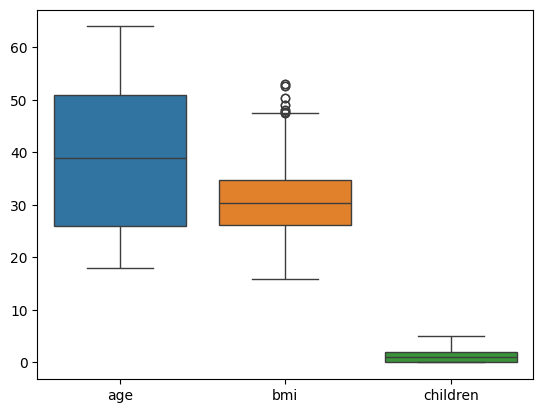

In [15]:
sns.boxplot(X)
plt.show()

In [16]:
num_cols=X.select_dtypes(include='number').columns
cat_cols=X.select_dtypes(include='object').columns

In [17]:
for col in num_cols:
    Q1=df[col].quantile(.25)
    Q3=df[col].quantile(.75)

    IQR=Q3-Q1

    lower=Q1 - 1.5*IQR
    upper=Q3 + 1.5*IQR

    outlier=df[(df[col]<lower) | (df[col]>upper)]

    print('\n',col)
    print('lower: ',lower)
    print('upper: ',upper)
    print('outliers: ',len(outlier))


 age
lower:  -11.5
upper:  88.5
outliers:  0

 bmi
lower:  13.394999999999992
upper:  47.59500000000001
outliers:  14

 children
lower:  -3.0
upper:  5.0
outliers:  0


In [18]:
for col in cat_cols:
    print('\n',col)
    print(df[col].unique())


 sex
['female' 'male']

 smoker
['yes' 'no']

 region
['southwest' 'southeast' 'northwest' 'northeast']


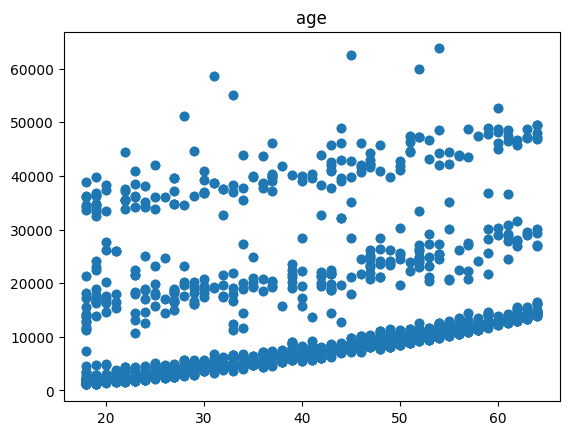

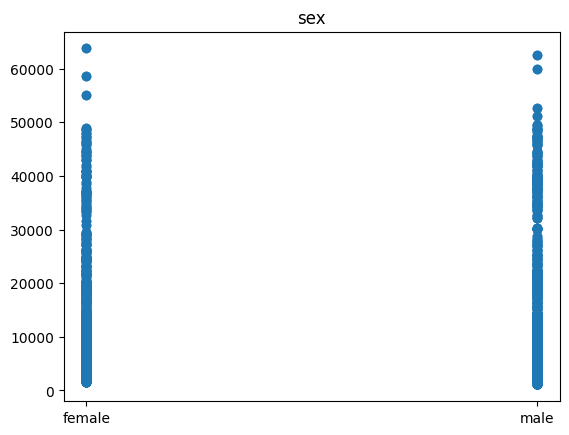

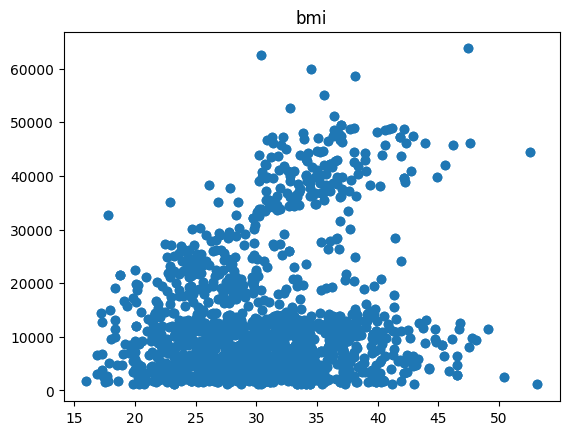

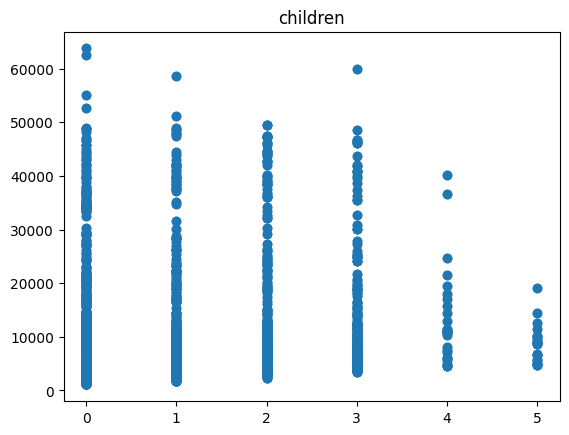

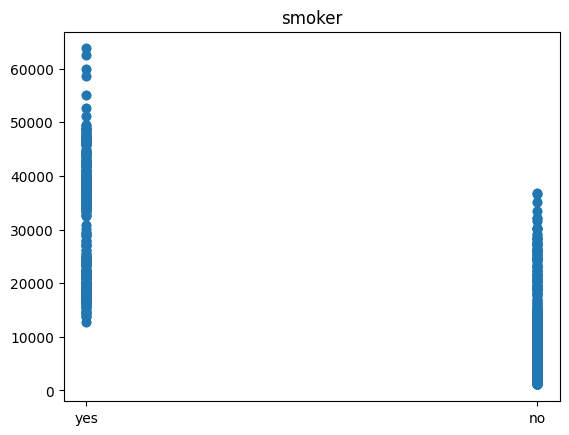

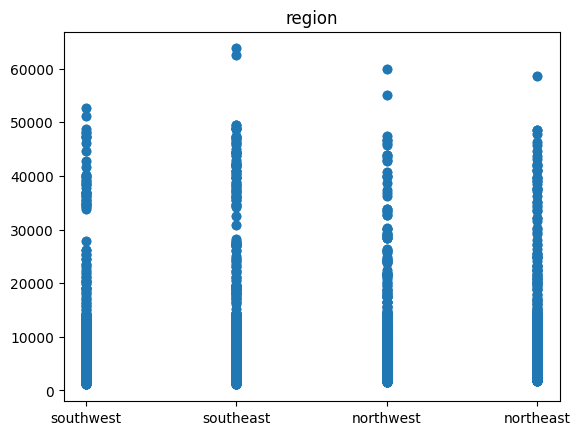

In [25]:
for col in X:   
    plt.title(col) 
    plt.scatter(df[col],y)
    plt.show()


In [27]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,train_size=0.8,random_state=42)

In [36]:
preprocess=ColumnTransformer(
    transformers=[('scaling',MinMaxScaler(),['age','children']),
                  ('std_scaling',StandardScaler(),['bmi']),
                  ('encoding',OneHotEncoder(handle_unknown='ignore'),cat_cols)
                  ],
    remainder='passthrough'
)

In [37]:
main_pipe=Pipeline(
    steps=[
        ('preprocessor',preprocess),
        ('model',DecisionTreeRegressor(random_state=42))
    ]
)

In [ ]:
main_pipe.fit(Xtrain,ytrain)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaling', ...), ('std_scaling', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
ypred_train=main_pipe.predict(Xtrain)
ypred_test=main_pipe.predict(Xtest)

In [ ]:
print('TRAIN: ')
print('r2_score: ',r2_score(ytrain,ypred_train))  
print('MAE: ',mean_absolute_error(ytrain,ypred_train))
print('RMSE: ',root_mean_squared_error(ytrain,ypred_train))

r2_score:  0.9997587266398212
MAE:  5.638798624267028
RMSE:  187.73897129232944


In [44]:
print('TEST: ')
print('r2_score: ',r2_score(ytest,ypred_test))
print('MAE: ',mean_absolute_error(ytest,ypred_test))
print('RMSE: ',root_mean_squared_error(ytest,ypred_test))

TEST: 
r2_score:  0.9546191368813611
MAE:  515.9016719099099
RMSE:  2639.1472692756456


### Random Forest

In [47]:
main_pipe_RF=Pipeline(
    steps=[
        ('preprocessor',preprocess),
        ('model',RandomForestRegressor(random_state=42))
    ]
)

In [48]:
main_pipe_RF.fit(Xtrain,ytrain)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaling', ...), ('std_scaling', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
ypred_train_RF=main_pipe_RF.predict(Xtrain)
ypred_test_RF=main_pipe_RF.predict(Xtest)

In [52]:
print('TRAIN: ')
print('r2_score: ',r2_score(ytrain,ypred_train_RF))
print('MAE: ',mean_absolute_error(ytrain,ypred_train_RF))
print('RMSE: ',root_mean_squared_error(ytrain,ypred_train_RF))

TRAIN: 
r2_score:  0.9921568259607554
MAE:  478.41332824305533
RMSE:  1070.3989479342947


In [53]:
print('TEST: ')
print('r2_score: ',r2_score(ytest,ypred_test_RF))
print('MAE: ',mean_absolute_error(ytest,ypred_test_RF))
print('RMSE: ',root_mean_squared_error(ytest,ypred_test_RF))

TEST: 
r2_score:  0.9518683948674672
MAE:  1277.4971072855672
RMSE:  2717.956001513264
